## Setup

In [1]:
import importlib, subprocess, sys
for pkg in ['torch', 'torchvision', 'matplotlib']:
    if importlib.util.find_spec(pkg) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

In [2]:
import os, json
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

os.makedirs('checkpoints', exist_ok=True)
os.makedirs('results', exist_ok=True)
os.makedirs('figures', exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

SEED = 0

import random
random.seed(SEED)

import torch
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

Using device: cuda


## Model: Logistic Regression (784 → 10)

In [3]:
class LogisticRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(784, 10)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.linear(x)

## Data Loader

In [4]:
BATCH_SIZE = 256

transform = transforms.ToTensor()

train_ds = datasets.MNIST('data', train=True, download=True, transform=transform)
test_ds = datasets.MNIST('data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=1000, shuffle=False)

print(f'Train: {len(train_ds):,} samples \nTest: {len(test_ds):,} samples')

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 493kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.62MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 22.7MB/s]

Train: 60,000 samples 
Test: 10,000 samples


## Binary Classification (3 vs 7)

Partial replication of Section 5 of "Explaining and Harnessing Adversarial Examples": binary logistic regression on MNIST digits 3 vs 7.

In [5]:
def make_binary_mnist_dataset(ds, neg_digit=3, pos_digit=7):
    mask = (ds.targets == neg_digit) | (ds.targets == pos_digit)
    x = ds.data[mask].unsqueeze(1).float() / 255.0
    y = (ds.targets[mask] == pos_digit).float()
    return torch.utils.data.TensorDataset(x, y)

binary_train_ds = make_binary_mnist_dataset(train_ds)
binary_test_ds = make_binary_mnist_dataset(test_ds)

binary_train_loader = DataLoader(binary_train_ds, batch_size=BATCH_SIZE, shuffle=True)
binary_test_loader = DataLoader(binary_test_ds, batch_size=1000, shuffle=False)

class BinaryLogisticRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(784, 1)

    def forward(self, x):
        return self.linear(x.view(x.size(0), -1)).squeeze(1)

def evaluate_binary_clean(model, loader):
    criterion = nn.BCEWithLogitsLoss()
    model.eval()
    total_loss, total, correct = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)
            loss = criterion(logits, y)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            total_loss += loss.item() * y.size(0)
            correct += (preds == y).sum().item()
            total += y.size(0)
    acc = correct / total
    return total_loss / total, acc, 1 - acc

def fgsm_attack_binary(model, x, y, epsilon):
    criterion = nn.BCEWithLogitsLoss()
    x_adv = x.clone().detach().requires_grad_(True)
    model.zero_grad()
    loss = criterion(model(x_adv), y)
    loss.backward()
    return (x_adv + epsilon * x_adv.grad.sign()).detach()

def evaluate_binary_adversarial(model, loader, epsilon):
    model.eval()
    total, correct = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if epsilon > 0:
            x = fgsm_attack_binary(model, x, y, epsilon)
        with torch.no_grad():
            logits = model(x)
            preds = (torch.sigmoid(logits) >= 0.5).float()
        correct += (preds == y).sum().item()
        total += y.size(0)
    acc = correct / total
    return acc, 1 - acc

print(f'Binary train size: {len(binary_train_ds):,}')
print(f'Binary test size: {len(binary_test_ds):,}')

Binary train size: 12,396
Binary test size: 2,038


In [6]:
BINARY_EPOCHS = 20
BINARY_LR = 0.01
BINARY_EPSILON = 0.25

binary_model = BinaryLogisticRegression().to(DEVICE)
binary_optimizer = optim.SGD(binary_model.parameters(), lr=BINARY_LR)
binary_criterion = nn.BCEWithLogitsLoss()

print(f'Training binary logistic regression (3 vs 7) for {BINARY_EPOCHS} epochs')
for epoch in range(1, BINARY_EPOCHS + 1):
    binary_model.train()
    for x, y in binary_train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        binary_optimizer.zero_grad()
        loss = binary_criterion(binary_model(x), y)
        loss.backward()
        binary_optimizer.step()

    if epoch % 5 == 0 or epoch == 1:
        _, tr_acc, tr_err = evaluate_binary_clean(binary_model, binary_train_loader)
        _, te_acc, te_err = evaluate_binary_clean(binary_model, binary_test_loader)
        print(f'\t Epoch {epoch:2d}: train_err={tr_err:.4f}  test_err={te_err:.4f}')

binary_clean_loss, binary_clean_acc, binary_clean_err = evaluate_binary_clean(binary_model, binary_test_loader)
binary_adv_acc, binary_adv_err = evaluate_binary_adversarial(binary_model, binary_test_loader, BINARY_EPSILON)

print('\nBinary logistic regression (3 vs 7)')
print(f'\t Clean test accuracy: {binary_clean_acc:.4f}')
print(f'\t Clean test error: {binary_clean_err:.4f}')
print(f'\t FGSM acc at ε={BINARY_EPSILON}: {binary_adv_acc:.4f}')
print(f'\t FGSM err at ε={BINARY_EPSILON}: {binary_adv_err:.4f}')

Training binary logistic regression (3 vs 7) for 20 epochs
	 Epoch  1: train_err=0.0349  test_err=0.0397
	 Epoch  5: train_err=0.0294  test_err=0.0353
	 Epoch 10: train_err=0.0264  test_err=0.0329
	 Epoch 15: train_err=0.0240  test_err=0.0314
	 Epoch 20: train_err=0.0230  test_err=0.0309

Binary logistic regression (3 vs 7)
	 Clean test accuracy: 0.9691
	 Clean test error: 0.0309
	 FGSM acc at ε=0.25: 0.0029
	 FGSM err at ε=0.25: 0.9971


## Train Clean Baseline

In [7]:
def evaluate_clean(model, loader):
    """
    Return (loss, accuracy) on a DataLoader
    """
    criterion = nn.CrossEntropyLoss()
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            out = model(x)
            total_loss += criterion(out, y).item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total   += y.size(0)
    return total_loss / total, correct / total

In [8]:
EPOCHS = 20
LR = 0.01

baseline_model = LogisticRegression().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(baseline_model.parameters(), lr=LR)

print(f'Training logistic regression for {EPOCHS} epochs')
for epoch in range(1, EPOCHS + 1):
    baseline_model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        criterion(baseline_model(x), y).backward()
        optimizer.step()

    if epoch % 5 == 0 or epoch == 1:
        _, tr_acc = evaluate_clean(baseline_model, train_loader)
        _, te_acc = evaluate_clean(baseline_model, test_loader)
        print(f'\tEpoch {epoch:2d}: train={tr_acc:.4f}  test={te_acc:.4f}')

_, clean_acc = evaluate_clean(baseline_model, test_loader)
print(f'\nFinal clean test accuracy: {clean_acc:.4f}')

torch.save(baseline_model.state_dict(), 'checkpoints/logreg_baseline.pt')
with open('results/baseline_clean_accuracy.json', 'w') as f:
    json.dump({'clean_accuracy': clean_acc}, f, indent=2)

Training logistic regression for 20 epochs
	Epoch  1: train=0.8104  test=0.8238
	Epoch  5: train=0.8652  test=0.8746
	Epoch 10: train=0.8807  test=0.8880
	Epoch 15: train=0.8887  test=0.8952
	Epoch 20: train=0.8938  test=0.9004

Final clean test accuracy: 0.9004


## FGSM Attack


In [9]:
def fgsm_attack(model, x, y, epsilon):
    """
    Return FGSM-perturbed inputs (in normalized pixel space)
    """
    criterion = nn.CrossEntropyLoss()
    x_adv = x.clone().detach().requires_grad_(True)
    loss = criterion(model(x_adv), y)
    loss.backward()
    x_adv = (x_adv + epsilon * x_adv.grad.sign()).detach()
    return x_adv


def evaluate_adversarial(model, loader, epsilon):
    """
    Accuracy under FGSM with given epsilon
    """
    model.eval()
    correct, total = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        if epsilon > 0:
            x = fgsm_attack(model, x, y, epsilon)
        with torch.no_grad():
            correct += (model(x).argmax(1) == y).sum().item()
        total += y.size(0)
    return correct / total

In [10]:
# Random-sign control and confidence statistics

def random_sign_attack(x, epsilon):
    noise = torch.empty_like(x).bernoulli_(0.5).mul_(2).sub_(1)
    return (x + epsilon * noise).detach()

def evaluate_attack_with_confidence(model, loader, epsilon, attack='clean'):
    model.eval()
    total, correct, incorrect = 0, 0, 0
    conf_sum, incorrect_conf_sum = 0.0, 0.0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        if attack == 'fgsm' and epsilon > 0:
            x = fgsm_attack(model, x, y, epsilon)
        elif attack == 'random_sign' and epsilon > 0:
            x = random_sign_attack(x, epsilon)
        elif attack != 'clean':
            raise ValueError(f'Unknown attack: {attack}')

        with torch.no_grad():
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            conf, pred = probs.max(dim=1)

        wrong = pred != y
        correct += (pred == y).sum().item()
        incorrect += wrong.sum().item()
        total += y.size(0)
        conf_sum += conf.sum().item()
        incorrect_conf_sum += conf[wrong].sum().item()

    acc = correct / total
    return {
        'accuracy': acc,
        'error_rate': 1 - acc,
        'mean_confidence': conf_sum / total,
        'mean_wrong_confidence': incorrect_conf_sum / max(incorrect, 1),
        'num_wrong': incorrect,
    }

CONTROL_EPSILON = 0.25

attack_stats = {
    'clean': evaluate_attack_with_confidence(baseline_model, test_loader, 0.0, attack='clean'),
    'random_sign': evaluate_attack_with_confidence(baseline_model, test_loader, CONTROL_EPSILON, attack='random_sign'),
    'fgsm': evaluate_attack_with_confidence(baseline_model, test_loader, CONTROL_EPSILON, attack='fgsm'),
}

print(f'Attack comparison at ε={CONTROL_EPSILON}')
for name, stats in attack_stats.items():
    print(
        f"{name:>12} | "
        f"acc={stats['accuracy']:.4f} | "
        f"err={stats['error_rate']:.4f} | "
        f"mean_conf={stats['mean_confidence']:.4f} | "
        f"mean_wrong_conf={stats['mean_wrong_confidence']:.4f}"
    )

Attack comparison at ε=0.25
       clean | acc=0.9004 | err=0.0996 | mean_conf=0.8168 | mean_wrong_conf=0.5204
 random_sign | acc=0.8892 | err=0.1108 | mean_conf=0.8107 | mean_wrong_conf=0.5307
        fgsm | acc=0.0002 | err=0.9998 | mean_conf=0.8029 | mean_wrong_conf=0.8030


## Epsilon Sweep — Baseline Model

In [11]:
EPSILONS = [0.0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]

print('Running FGSM epsilon sweep on baseline')
baseline_adv_accs = []
for eps in EPSILONS:
    acc = evaluate_adversarial(baseline_model, test_loader, eps)
    baseline_adv_accs.append(acc)
    print(f'\tepsilon={eps:.2f}  accuracy={acc:.4f}')

with open('results/logreg_fgsm_results.json', 'w') as f:
    json.dump({'epsilons': EPSILONS, 'adversarial_accuracies': baseline_adv_accs}, f, indent=2)

Running FGSM epsilon sweep on baseline
	epsilon=0.00  accuracy=0.9004
	epsilon=0.05  accuracy=0.6195
	epsilon=0.10  accuracy=0.1983
	epsilon=0.15  accuracy=0.0251
	epsilon=0.20  accuracy=0.0018
	epsilon=0.25  accuracy=0.0002
	epsilon=0.30  accuracy=0.0000
	epsilon=0.35  accuracy=0.0000
	epsilon=0.40  accuracy=0.0000
	epsilon=0.45  accuracy=0.0000
	epsilon=0.50  accuracy=0.0000


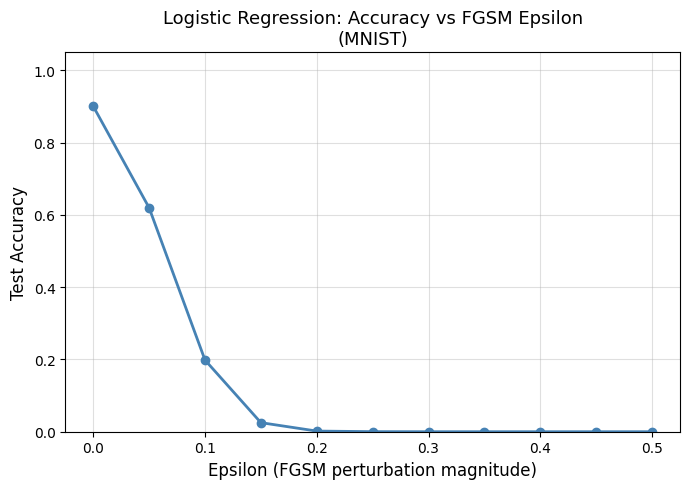

In [12]:
plt.figure(figsize=(7, 5))
plt.plot(EPSILONS, baseline_adv_accs, marker='o', linewidth=2, color='steelblue')
plt.xlabel('Epsilon (FGSM perturbation magnitude)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Logistic Regression: Accuracy vs FGSM Epsilon\n(MNIST)', fontsize=13)
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('figures/logreg_fgsm_accuracy_vs_epsilon.png', dpi=150)
plt.show()

## Linearity Hypothesis

Test the first-order explanation of FGSM by comparing, for each example, the predicted loss increase from the linear approximation, $\epsilon \|\nabla_x J(x, y)\|_1$, to the actual loss increase, $J(x_{adv}, y) - J(x, y)$. For each $\epsilon$, we report the mean predicted increase, the mean actual increase, and the Pearson correlation across examples.

First-order analysis
 epsilon     mean pred   mean actual      corr
--------------------------------------------------
    0.01        0.0902        0.0999    0.9985
    0.05        0.4509        0.7349    0.9643
    0.10        0.9018        2.1395    0.8912
    0.25        2.2546        8.4114    0.7863


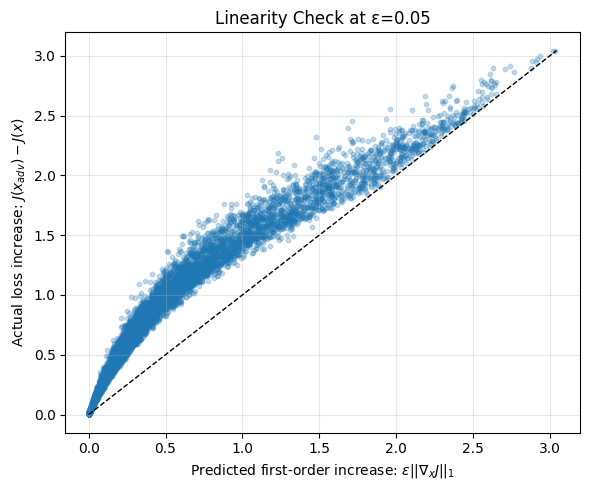

In [13]:
def pearson_corr(x, y):
    x = x.float().flatten()
    y = y.float().flatten()
    x = x - x.mean()
    y = y - y.mean()
    return (x * y).mean() / (x.std(unbiased=False) * y.std(unbiased=False) + 1e-12)

def collect_first_order_stats(model, loader, epsilon, num_batches=10):
    model.eval()
    linear_terms = []
    actual_deltas = []

    for batch_idx, (x, y) in enumerate(loader):
        if batch_idx >= num_batches:
            break

        x, y = x.to(DEVICE), y.to(DEVICE)
        x0 = x.clone().detach().requires_grad_(True)

        clean_logits = model(x0)
        clean_loss_per = nn.functional.cross_entropy(clean_logits, y, reduction='none')

        # Gradient of the SUM of per-sample losses gives correctly scaled per-sample grads
        grad = torch.autograd.grad(clean_loss_per.sum(), x0)[0].detach()

        # First-order Taylor prediction for FGSM under L_inf budget
        linear_term = epsilon * grad.view(grad.size(0), -1).abs().sum(dim=1)

        x_adv = (x + epsilon * grad.sign()).detach()
        with torch.no_grad():
            adv_logits = model(x_adv)
            adv_loss_per = nn.functional.cross_entropy(adv_logits, y, reduction='none')

        delta_loss = adv_loss_per - clean_loss_per.detach()

        linear_terms.append(linear_term.cpu())
        actual_deltas.append(delta_loss.cpu())

    linear_terms = torch.cat(linear_terms)
    actual_deltas = torch.cat(actual_deltas)
    corr = pearson_corr(linear_terms, actual_deltas).item()

    return {
        'predicted': linear_terms,
        'actual': actual_deltas,
        'corr': corr,
        'mean_predicted': linear_terms.mean().item(),
        'mean_actual': actual_deltas.mean().item(),
    }

ANALYSIS_EPSILONS = [0.01, 0.05, 0.10, 0.25]
NUM_ANALYSIS_BATCHES = 10

analysis_results = {}
for eps in ANALYSIS_EPSILONS:
    analysis_results[eps] = collect_first_order_stats(
        baseline_model,
        test_loader,
        epsilon=eps,
        num_batches=NUM_ANALYSIS_BATCHES,
    )

print('First-order analysis')
print(f'{"epsilon":>8}  {"mean pred":>12}  {"mean actual":>12}  {"corr":>8}')
print('-' * 50)
for eps in ANALYSIS_EPSILONS:
    r = analysis_results[eps]
    print(f'{eps:>8.2f}  {r["mean_predicted"]:>12.4f}  {r["mean_actual"]:>12.4f}  {r["corr"]:>8.4f}')

PLOT_EPSILON = 0.05
pred = analysis_results[PLOT_EPSILON]['predicted']
actual = analysis_results[PLOT_EPSILON]['actual']

plt.figure(figsize=(6, 5))
plt.scatter(pred.numpy(), actual.numpy(), s=10, alpha=0.25)
lim = max(pred.max().item(), actual.max().item())
plt.plot([0, lim], [0, lim], '--', linewidth=1, color='black')
plt.xlabel(r'Predicted first-order increase: $\epsilon ||\nabla_x  J||_1$')
plt.ylabel(r'Actual loss increase: $J(x_{adv}) - J(x)$')
plt.title(f'Linearity Check at ε={PLOT_EPSILON}')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [14]:
print(f'Clean accuracy (epsilon=0):  {baseline_adv_accs[0]:.4f}')
for eps, acc in zip(EPSILONS[1:], baseline_adv_accs[1:]):
    drop = baseline_adv_accs[0] - acc
    print(f'\tepsilon={eps:.2f} \taccuracy={acc:.4f}  (dropped by={drop:.4f})')

Clean accuracy (epsilon=0):  0.9004
	epsilon=0.05 	accuracy=0.6195  (dropped by=0.2809)
	epsilon=0.10 	accuracy=0.1983  (dropped by=0.7021)
	epsilon=0.15 	accuracy=0.0251  (dropped by=0.8753)
	epsilon=0.20 	accuracy=0.0018  (dropped by=0.8986)
	epsilon=0.25 	accuracy=0.0002  (dropped by=0.9002)
	epsilon=0.30 	accuracy=0.0000  (dropped by=0.9004)
	epsilon=0.35 	accuracy=0.0000  (dropped by=0.9004)
	epsilon=0.40 	accuracy=0.0000  (dropped by=0.9004)
	epsilon=0.45 	accuracy=0.0000  (dropped by=0.9004)
	epsilon=0.50 	accuracy=0.0000  (dropped by=0.9004)


For binary logistic regression, Goodfellow et al. show that the FGSM direction is exact under an $L_\infty$ constraint. Here we verify that the input-gradient sign matches the theoretical sign pattern implied by the learned weight vector, and we connect this to the dimensionality-scaling argument that the activation shift grows like $\epsilon m n$. Here, near-perfect agreement is expected and should be interpreted as a sanity check on the theory.

In [15]:
binary_model.eval()
w = binary_model.linear.weight.detach().cpu().view(-1)  # shape (784,)
sign_w = w.sign()

criterion_bin = nn.BCEWithLogitsLoss(reduction='none')
all_agreements = []

for x, y in binary_test_loader:
    x, y = x.to(DEVICE), y.to(DEVICE)
    x_req = x.clone().detach().requires_grad_(True)
    loss = criterion_bin(binary_model(x_req), y).sum()
    loss.backward()
    grad = x_req.grad.detach().cpu().view(x.size(0), -1)  # (N, 784)
    sign_grad = grad.sign()

    # Correctly classified y=1: σ(z)>0.5  →  scalar<0  →  sign_grad ≈ −sign(w)
    # Correctly classified y=0: σ(z)<0.5  →  scalar>0  →  sign_grad ≈ +sign(w)
    y_cpu = y.cpu()
    predicted = torch.where(
        y_cpu.unsqueeze(1) == 1,
        -sign_w.unsqueeze(0),
         sign_w.unsqueeze(0),
    )
    agreement = (sign_grad == predicted).float().mean(dim=1)
    all_agreements.append(agreement)

all_agreements = torch.cat(all_agreements)
print('Gradient-sign check:')
print(f'\tAverage agreement with the theoretical sign pattern: {all_agreements.mean():.4f} ± {all_agreements.std():.4f}')
print('\tThis is exactly what we expect for binary logistic regression, so it is mainly a sanity check.')

n = 784
m = w.abs().mean().item()
l1_norm = w.abs().sum().item()
growth = BINARY_EPSILON * l1_norm
print(f'\nDimensionality scaling:')
print(f'\tThe model has n = {n} input dimensions and mean |w_i| = {m:.5f}, so ||w||_1 = {l1_norm:.3f}.')
print(f'\tAt ε = {BINARY_EPSILON}, the predicted logit shift is ε||w||_1 = {BINARY_EPSILON} × {l1_norm:.3f} = {growth:.3f}.')
print(f'\tSo even though each pixel moves by at most {BINARY_EPSILON}, the changes add up across all {n} dimensions.')
print(f'\tEquivalently, the total logit shift is about {l1_norm:.1f} × ε.')


Gradient-sign check:
	Average agreement with the theoretical sign pattern: 1.0000 ± 0.0000
	This is exactly what we expect for binary logistic regression, so it is mainly a sanity check.

Dimensionality scaling:
	The model has n = 784 input dimensions and mean |w_i| = 0.04248, so ||w||_1 = 33.302.
	At ε = 0.25, the predicted logit shift is ε||w||_1 = 0.25 × 33.302 = 8.325.
	So even though each pixel moves by at most 0.25, the changes add up across all 784 dimensions.
	Equivalently, the total logit shift is about 33.3 × ε.


## Adversarial Training

In [16]:
ADV_EPSILON = 0.25

adv_model = LogisticRegression().to(DEVICE)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(adv_model.parameters(), lr=LR)

print(f'Adversarial training (epsilon={ADV_EPSILON}) for {EPOCHS} epochs')
for epoch in range(1, EPOCHS + 1):
    adv_model.train()
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        x_adv = fgsm_attack(adv_model, x, y, ADV_EPSILON)
        x_mixed = torch.cat([x, x_adv], dim=0)
        y_mixed = torch.cat([y, y], dim=0)

        adv_model.train()
        optimizer.zero_grad()
        criterion(adv_model(x_mixed), y_mixed).backward()
        optimizer.step()

    if epoch % 5 == 0 or epoch == 1:
        c_acc = evaluate_adversarial(adv_model, test_loader, 0.0)
        a_acc = evaluate_adversarial(adv_model, test_loader, ADV_EPSILON)
        print(f'\tEpoch {epoch:2d}: clean={c_acc:.4f}, adv(ε={ADV_EPSILON})={a_acc:.4f}')

torch.save(adv_model.state_dict(), 'checkpoints/logreg_adv_trained.pt')

Adversarial training (epsilon=0.25) for 20 epochs
	Epoch  1: clean=0.7865, adv(ε=0.25)=0.1036
	Epoch  5: clean=0.8113, adv(ε=0.25)=0.1325
	Epoch 10: clean=0.8142, adv(ε=0.25)=0.1370
	Epoch 15: clean=0.8133, adv(ε=0.25)=0.1410
	Epoch 20: clean=0.8146, adv(ε=0.25)=0.1402


## L1 Weight Decay vs Adversarial Training

This section examines the comparison in section 5 of Goodfellow et al. The paper argues that adversarial training for logistic regression behaves similarly to an input-dependent $L_1$-style penalty, but is less pessimistic than standard $L_1$ weight decay because its effect depends on the current example and can diminish once the model has sufficient margin.

Here we train three $L_1$-regularized logistic-regression models and compare their FGSM robustness curves to the naturally trained baseline.


In [17]:
L1_LAMBDAS = [0.0001, 0.001, 0.005]

l1_models = {}
l1_clean_accs = {}
l1_adv_accs = {lam: [] for lam in L1_LAMBDAS}
l1_criterion = nn.CrossEntropyLoss()

for lam in L1_LAMBDAS:
    model_l1 = LogisticRegression().to(DEVICE)
    opt_l1 = optim.SGD(model_l1.parameters(), lr=LR)

    for epoch in range(1, EPOCHS + 1):
        model_l1.train()
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            opt_l1.zero_grad()
            loss = l1_criterion(model_l1(x), y) + lam * model_l1.linear.weight.abs().sum()
            loss.backward()
            opt_l1.step()

    _, clean_acc = evaluate_clean(model_l1, test_loader)
    l1_models[lam] = model_l1
    l1_clean_accs[lam] = clean_acc
    for eps in EPSILONS:
        l1_adv_accs[lam].append(evaluate_adversarial(model_l1, test_loader, eps))
    print(f'L1 λ={lam:.4f}: clean={clean_acc:.4f}  adv(ε=0.25)={l1_adv_accs[lam][5]:.4f}')


L1 λ=0.0001: clean=0.8984  adv(ε=0.25)=0.0003
L1 λ=0.0010: clean=0.8911  adv(ε=0.25)=0.0043
L1 λ=0.0050: clean=0.8576  adv(ε=0.25)=0.0234


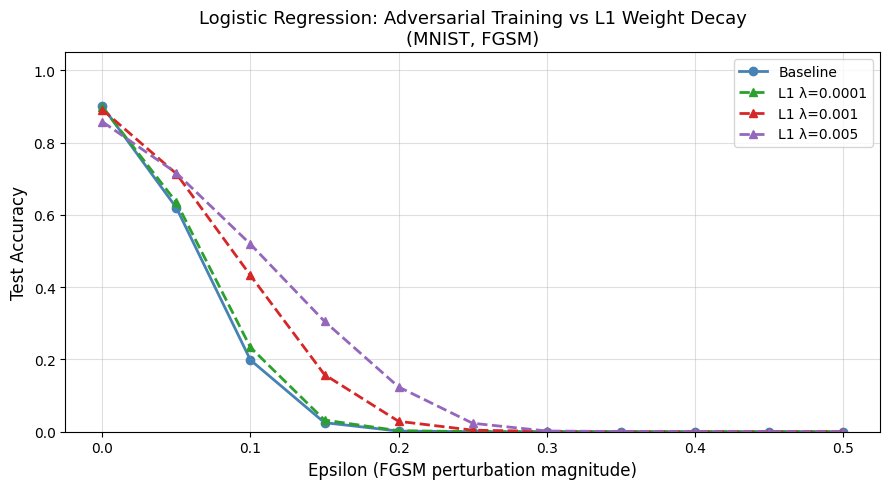

In [18]:
plt.figure(figsize=(9, 5))
plt.plot(EPSILONS, baseline_adv_accs, marker='o', linewidth=2,
         color='steelblue', label='Baseline')

l1_colors = ['#2ca02c', '#d62728', '#9467bd']
for lam, color in zip(L1_LAMBDAS, l1_colors):
    plt.plot(EPSILONS, l1_adv_accs[lam], marker='^', linewidth=2,
             linestyle='--', color=color, label=f'L1 λ={lam}')

plt.xlabel('Epsilon (FGSM perturbation magnitude)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Logistic Regression: Adversarial Training vs L1 Weight Decay\n(MNIST, FGSM)', fontsize=13)
plt.ylim(0, 1.05)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('figures/logreg_adv_vs_l1.png', dpi=150)
plt.show()


## Baseline vs Adversarially Trained

In [19]:
print('Epsilon sweep: baseline vs adversarially trained')
adv_trained_accs = []
for eps in EPSILONS:
    b_acc = evaluate_adversarial(baseline_model, test_loader, eps)
    a_acc = evaluate_adversarial(adv_model, test_loader, eps)
    adv_trained_accs.append(a_acc)
    print(f'\tepsilon={eps:.2f}  baseline={b_acc:.4f}  adv_trained={a_acc:.4f}')

with open('results/logreg_adv_training_results.json', 'w') as f:
    json.dump({
        'epsilons': EPSILONS,
        'baseline_accuracies': baseline_adv_accs,
        'adv_trained_accuracies': adv_trained_accs,
        'adv_train_epsilon': ADV_EPSILON,
    }, f, indent=2)

Epsilon sweep: baseline vs adversarially trained
	epsilon=0.00  baseline=0.9004  adv_trained=0.8146
	epsilon=0.05  baseline=0.6195  adv_trained=0.7071
	epsilon=0.10  baseline=0.1983  adv_trained=0.5730
	epsilon=0.15  baseline=0.0251  adv_trained=0.4186
	epsilon=0.20  baseline=0.0018  adv_trained=0.2696
	epsilon=0.25  baseline=0.0002  adv_trained=0.1402
	epsilon=0.30  baseline=0.0000  adv_trained=0.0447
	epsilon=0.35  baseline=0.0000  adv_trained=0.0074
	epsilon=0.40  baseline=0.0000  adv_trained=0.0005
	epsilon=0.45  baseline=0.0000  adv_trained=0.0000
	epsilon=0.50  baseline=0.0000  adv_trained=0.0000


In [20]:
print(f'\n{"Epsilon":>8}  {"Baseline":>10}  {"Adv-Trained":>12}')
print('-' * 36)
for eps, b, a in zip(EPSILONS, baseline_adv_accs, adv_trained_accs):
    print(f'{eps:>8.2f}  {b:>10.4f}  {a:>12.4f}')


 Epsilon    Baseline   Adv-Trained
------------------------------------
    0.00      0.9004        0.8146
    0.05      0.6195        0.7071
    0.10      0.1983        0.5730
    0.15      0.0251        0.4186
    0.20      0.0018        0.2696
    0.25      0.0002        0.1402
    0.30      0.0000        0.0447
    0.35      0.0000        0.0074
    0.40      0.0000        0.0005
    0.45      0.0000        0.0000
    0.50      0.0000        0.0000


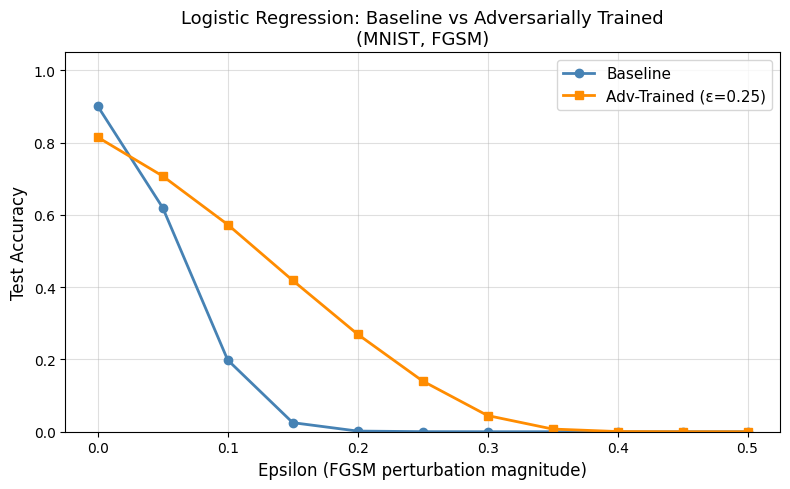

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(EPSILONS, baseline_adv_accs, marker='o', linewidth=2, color='steelblue', label='Baseline')
plt.plot(EPSILONS, adv_trained_accs, marker='s', linewidth=2, color='darkorange', label=f'Adv-Trained (ε={ADV_EPSILON})')
plt.xlabel('Epsilon (FGSM perturbation magnitude)', fontsize=12)
plt.ylabel('Test Accuracy', fontsize=12)
plt.title('Logistic Regression: Baseline vs Adversarially Trained\n(MNIST, FGSM)', fontsize=13)
plt.ylim(0, 1.05)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('figures/logreg_baseline_vs_adv_trained.png', dpi=150)
plt.show()

## Results

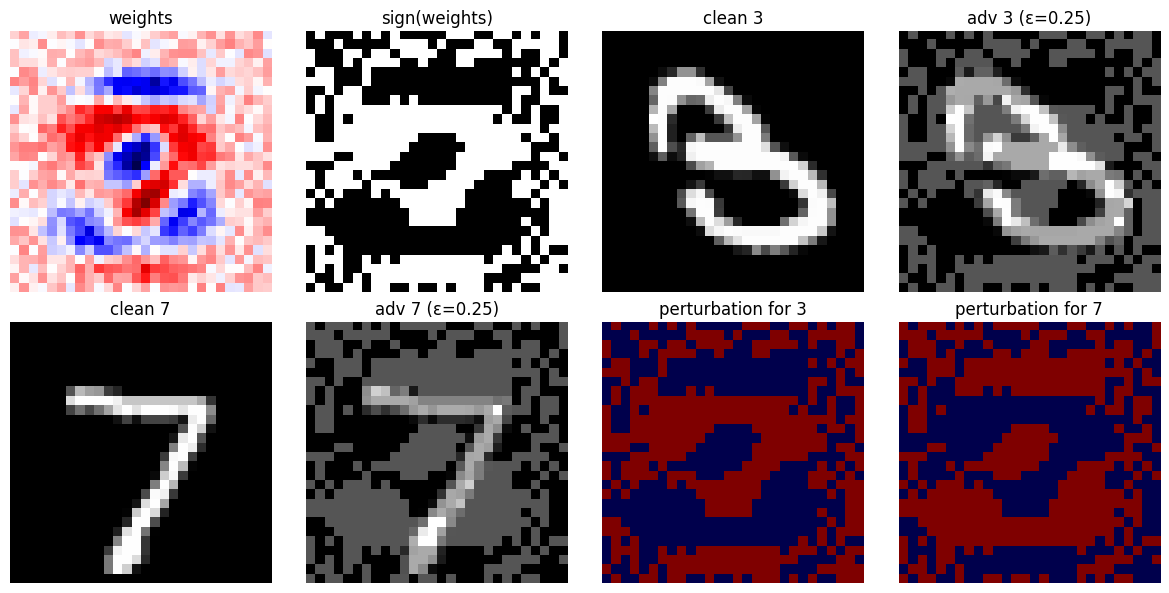

Binary clean error: 		0.0309
Binary FGSM error @ ε=.25: 	0.9971


In [22]:
# Visualization for the binary linear model

binary_model.eval()
weight_img = binary_model.linear.weight.detach().cpu().view(28, 28)

x_vis, y_vis = next(iter(binary_test_loader))
idx_3 = (y_vis == 0).nonzero(as_tuple=True)[0][0].item()
idx_7 = (y_vis == 1).nonzero(as_tuple=True)[0][0].item()

x_pair = torch.stack([x_vis[idx_3], x_vis[idx_7]]).to(DEVICE)
y_pair = torch.tensor([0.0, 1.0], device=DEVICE)
x_pair_adv = fgsm_attack_binary(binary_model, x_pair, y_pair, BINARY_EPSILON).cpu()
x_pair = x_pair.cpu()
perturb = x_pair_adv - x_pair

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

axes[0,0].imshow(weight_img, cmap='seismic')
axes[0,0].set_title('weights')
axes[0,1].imshow(weight_img.sign(), cmap='gray', vmin=-1, vmax=1)
axes[0,1].set_title('sign(weights)')
axes[0,2].imshow(x_pair[0, 0], cmap='gray')
axes[0,2].set_title('clean 3')
axes[0,3].imshow(x_pair_adv[0, 0], cmap='gray')
axes[0,3].set_title(f'adv 3 (ε={BINARY_EPSILON})')

axes[1,0].imshow(x_pair[1, 0], cmap='gray')
axes[1,0].set_title('clean 7')
axes[1,1].imshow(x_pair_adv[1, 0], cmap='gray')
axes[1,1].set_title(f'adv 7 (ε={BINARY_EPSILON})')
axes[1,2].imshow(perturb[0, 0], cmap='seismic', vmin=-BINARY_EPSILON, vmax=BINARY_EPSILON)
axes[1,2].set_title('perturbation for 3')
axes[1,3].imshow(perturb[1, 0], cmap='seismic', vmin=-BINARY_EPSILON, vmax=BINARY_EPSILON)
axes[1,3].set_title('perturbation for 7')

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f'Binary clean error: \t\t{binary_clean_err:.4f}')
print(f'Binary FGSM error @ ε=.25: \t{binary_adv_err:.4f}')

In [24]:

print('Summary of Results for Logistic Regression on MNIST')
print('=' * 50)
print(f'Clean baseline accuracy: \t{baseline_adv_accs[0]:.4f}')
print(f'Adv-trained clean accuracy: \t{adv_trained_accs[0]:.4f}')
print(f'Baseline accuracy at ε=0.1: \t{baseline_adv_accs[2]:.4f}')
print(f'Adv-trained accuracy at ε=0.1: \t{adv_trained_accs[2]:.4f}')
print(f'Baseline accuracy at ε=0.25: \t{baseline_adv_accs[5]:.4f}')
print(f'Adv-trained accuracy at ε=0.25: {adv_trained_accs[5]:.4f}')

Summary of Results for Logistic Regression on MNIST
Clean baseline accuracy: 	0.9004
Adv-trained clean accuracy: 	0.8146
Baseline accuracy at ε=0.1: 	0.1983
Adv-trained accuracy at ε=0.1: 	0.5730
Baseline accuracy at ε=0.25: 	0.0002
Adv-trained accuracy at ε=0.25: 0.1402
